In [6]:
# @title NurseSchedulingProblem Class
import numpy as np

class NurseSchedulingProblem:
    """This class encapsulates the Nurse Scheduling problem
    """

    def __init__(self, hardConstraintPenalty):
        """
        :param hardConstraintPenalty: the penalty factor for a hard-constraint violation
        """
        self.hardConstraintPenalty = hardConstraintPenalty

        # list of nurses:
        self.nurses = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

        # nurses' respective shift preferences - morning, evening, night:
        self.shiftPreference = [[1, 0, 0], [1, 1, 0], [0, 0, 1], [0, 1, 0], [0, 0, 1], [1, 1, 1], [0, 1, 1], [1, 1, 1]]

        # min and max number of nurses allowed for each shift - morning, evening, night:
        self.shiftMin = [2, 2, 1]
        self.shiftMax = [3, 4, 2]

        # max shifts per week allowed for each nurse
        self.maxShiftsPerWeek = 5

        # number of weeks we create a schedule for:
        self.weeks = 1

        # useful values:
        self.shiftPerDay = len(self.shiftMin)
        self.shiftsPerWeek = 7 * self.shiftPerDay

    def __len__(self):
        """
        :return: the number of shifts in the schedule
        """
        return len(self.nurses) * self.shiftsPerWeek * self.weeks


    def getCost(self, schedule):
        """
        Calculates the total cost of the various violations in the given schedule
        ...
        :param schedule: a list of binary values describing the given schedule
        :return: the calculated cost
        """

        if len(schedule) != self.__len__():
            raise ValueError("size of schedule list should be equal to ", self.__len__())

        # convert entire schedule into a dictionary with a separate schedule for each nurse:
        nurseShiftsDict = self.getNurseShifts(schedule)

        # count the various violations:
        consecutiveShiftViolations = self.countConsecutiveShiftViolations(nurseShiftsDict)
        shiftsPerWeekViolations = self.countShiftsPerWeekViolations(nurseShiftsDict)[1]
        nursesPerShiftViolations = self.countNursesPerShiftViolations(nurseShiftsDict)[1]
        shiftPreferenceViolations = self.countShiftPreferenceViolations(nurseShiftsDict)

        # calculate the cost of the violations:
        hardContstraintViolations = consecutiveShiftViolations + nursesPerShiftViolations + shiftsPerWeekViolations
        softContstraintViolations = shiftPreferenceViolations

        return self.hardConstraintPenalty * hardContstraintViolations + softContstraintViolations

    def getNurseShifts(self, schedule):
        """
        Converts the entire schedule into a dictionary with a separate schedule for each nurse
        :param schedule: a list of binary values describing the given schedule
        :return: a dictionary with each nurse as a key and the corresponding shifts as the value
        """
        shiftsPerNurse = self.__len__() // len(self.nurses)
        nurseShiftsDict = {}
        shiftIndex = 0

        for nurse in self.nurses:
            nurseShiftsDict[nurse] = schedule[shiftIndex:shiftIndex + shiftsPerNurse]
            shiftIndex += shiftsPerNurse

        return nurseShiftsDict

    def countConsecutiveShiftViolations(self, nurseShiftsDict):
        """
        Counts the consecutive shift violations in the schedule
        :param nurseShiftsDict: a dictionary with a separate schedule for each nurse
        :return: count of violations found
        """
        violations = 0
        # iterate over the shifts of each nurse:
        for nurseShifts in nurseShiftsDict.values():
            # look for two cosecutive '1's:
            for shift1, shift2 in zip(nurseShifts, nurseShifts[1:]):
                if shift1 == 1 and shift2 == 1:
                    violations += 1
        return violations

    def countShiftsPerWeekViolations(self, nurseShiftsDict):
        """
        Counts the max-shifts-per-week violations in the schedule
        :param nurseShiftsDict: a dictionary with a separate schedule for each nurse
        :return: count of violations found
        """
        violations = 0
        weeklyShiftsList = []
        # iterate over the shifts of each nurse:
        for nurseShifts in nurseShiftsDict.values():  # all shifts of a single nurse
            # iterate over the shifts of each weeks:
            for i in range(0, self.weeks * self.shiftsPerWeek, self.shiftsPerWeek):
                # count all the '1's over the week:
                weeklyShifts = sum(nurseShifts[i:i + self.shiftsPerWeek])
                weeklyShiftsList.append(weeklyShifts)
                if weeklyShifts > self.maxShiftsPerWeek:
                    violations += weeklyShifts - self.maxShiftsPerWeek

        return weeklyShiftsList, violations

    def countNursesPerShiftViolations(self, nurseShiftsDict):
        """
        Counts the number-of-nurses-per-shift violations in the schedule
        :param nurseShiftsDict: a dictionary with a separate schedule for each nurse
        :return: count of violations found
        """
        # sum the shifts over all nurses:
        totalPerShiftList = [sum(shift) for shift in zip(*nurseShiftsDict.values())]

        violations = 0
        # iterate over all shifts and count violations:
        for shiftIndex, numOfNurses in enumerate(totalPerShiftList):
            dailyShiftIndex = shiftIndex % self.shiftPerDay  # -> 0, 1, or 2 for the 3 shifts per day
            if (numOfNurses > self.shiftMax[dailyShiftIndex]):
                violations += numOfNurses - self.shiftMax[dailyShiftIndex]
            elif (numOfNurses < self.shiftMin[dailyShiftIndex]):
                violations += self.shiftMin[dailyShiftIndex] - numOfNurses

        return totalPerShiftList, violations

    def countShiftPreferenceViolations(self, nurseShiftsDict):
        """
        Counts the nurse-preferences violations in the schedule
        :param nurseShiftsDict: a dictionary with a separate schedule for each nurse
        :return: count of violations found
        """
        violations = 0
        for nurseIndex, shiftPreference in enumerate(self.shiftPreference):
            # duplicate the shift-preference over the days of the period
            preference = shiftPreference * (self.shiftsPerWeek // self.shiftPerDay)
            # iterate over the shifts and compare to preferences:
            shifts = nurseShiftsDict[self.nurses[nurseIndex]]
            for pref, shift in zip(preference, shifts):
                if pref == 0 and shift == 1:
                    violations += 1

        return violations

    def printScheduleInfo(self, schedule):
        """
        Prints the schedule and violations details
        :param schedule: a list of binary values describing the given schedule
        """
        nurseShiftsDict = self.getNurseShifts(schedule)

        print("Schedule for each nurse:")
        for nurse in nurseShiftsDict:  # all shifts of a single nurse
            print(nurse, ":", nurseShiftsDict[nurse])

        print("consecutive shift violations = ", self.countConsecutiveShiftViolations(nurseShiftsDict))
        print()

        weeklyShiftsList, violations = self.countShiftsPerWeekViolations(nurseShiftsDict)
        print("weekly Shifts = ", weeklyShiftsList)
        print("Shifts Per Week Violations = ", violations)
        print()

        totalPerShiftList, violations = self.countNursesPerShiftViolations(nurseShiftsDict)
        print("Nurses Per Shift = ", totalPerShiftList)
        print("Nurses Per Shift Violations = ", violations)
        print()

        shiftPreferenceViolations = self.countShiftPreferenceViolations(nurseShiftsDict)
        print("Shift Preference Violations = ", shiftPreferenceViolations)
        print()

In [2]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


In [7]:
from deap import base, creator, tools, algorithms

import random
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# problem constants:
HARD_CONSTRAINT_PENALTY = 10  # the penalty factor for a hard-constraint violation

# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 200
HALL_OF_FAME_SIZE = 30

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [ ]:
toolbox = base.Toolbox()

# create the nurse scheduling problem instance to be used:
nsp = NurseSchedulingProblem(HARD_CONSTRAINT_PENALTY)

In [9]:
# define a single objective, maximizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, len(nsp))

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

In [10]:
# fitness calculation
def getCost(individual):
    return nsp.getCost(individual),  # return a tuple


toolbox.register("evaluate", getCost)

In [11]:
# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/len(nsp))

In [14]:
# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", numpy.min)
stats.register("avg", numpy.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# perform the Genetic Algorithm flowd:
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                          ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

# print best solution found:
best = hof.items[0]
print("-- Best Individual = ", best)
print("-- Best Fitness = ", best.fitness.values[0])
print()
print("-- Schedule = ")
nsp.printScheduleInfo(best)

# extract statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

gen	nevals	min	avg    
0  	300   	614	1146.95
1  	275   	639	1045.4 
2  	276   	524	954.787
3  	267   	554	881.66 
4  	258   	513	808.837
5  	258   	427	740.47 
6  	271   	421	675.52 
7  	269   	315	631.453
8  	274   	294	569.87 
9  	271   	254	510.073
10 	271   	222	453.06 
11 	275   	181	412.68 
12 	271   	181	365.98 
13 	256   	146	326.883
14 	263   	145	298.3  
15 	269   	127	268.913
16 	265   	116	245.43 
17 	284   	96 	221.513
18 	285   	99 	200.363
19 	274   	74 	177.807
20 	266   	65 	165.657
21 	273   	55 	154.273
22 	262   	76 	140.613
23 	266   	74 	132.93 
24 	272   	58 	120.327
25 	274   	62 	115.18 
26 	275   	62 	108.72 
27 	283   	52 	102.827
28 	257   	56 	98.8867
29 	271   	53 	95.1333
30 	287   	56 	91.02  
31 	270   	46 	87.9333
32 	272   	36 	85.58  
33 	282   	38 	82.5967
34 	280   	35 	78.0967
35 	263   	27 	73.8733
36 	276   	27 	70.3867
37 	271   	25 	65.1267
38 	269   	24 	62.95  
39 	277   	24 	59.7267
40 	281   	24 	55.0567
41 	268   	24 	52.2833
42 	273   	

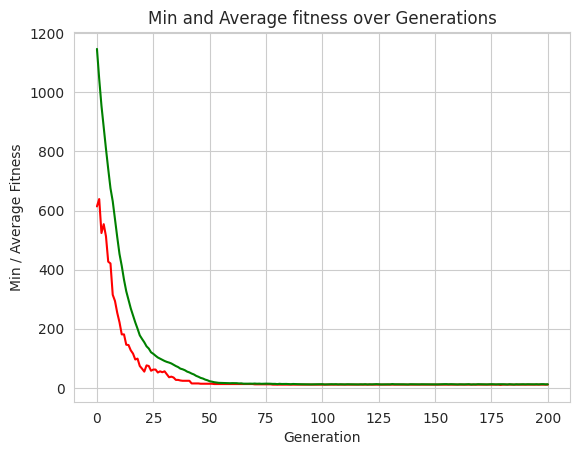

In [15]:
# plot statistics:
sns.set_style("whitegrid")
plt.plot(minFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')
plt.show()
